# **Trabajo Practico N° 3**
**Grupo 3: Nuñez Juliana, Segovia Lucas**

**Importaciones:**

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(42)

### **Actividad 1:**

El archivo data_1.txt tiene datos del precio de viviendas en función de la población de la ciudad, o sea:

* **Variable independiente (x)**: Población (en unidades de 10.000 habitantes).  
* **Variable objetivo (y)**: Precio de la vivienda (en unidades de 10.000 dólares). 

**Carga y visualización de datos**: importamos los datos desde el archivo de texto y generamos un gráfico de dispersión para observar la relación inicial entre ambas variables.

Text(0.5, 1.0, 'Población vs Precio de vivienda')

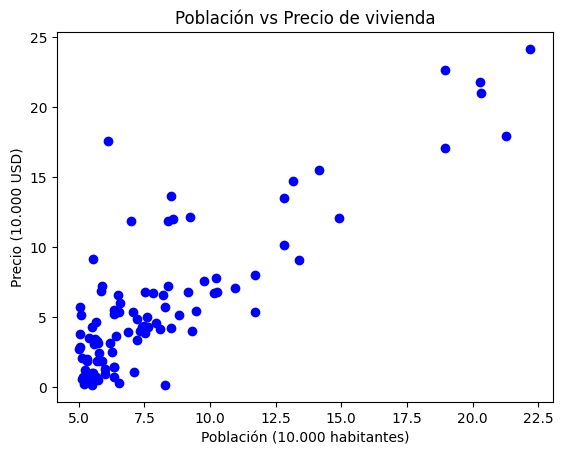

In [3]:
data1 = np.loadtxt('data/data_1.txt', delimiter=',')
# En scikit-learn, la X tiene que ser una matriz de 2 dimensiones, por eso usamos .reshape(-1, 1). La y puede ser un vector simple.
X = data1[:, 0].reshape(-1, 1) 
y = data1[:, 1]

# Diagrama de dispersión
plt.scatter(X, y, color='blue', label='Datos reales')
plt.xlabel('Población (10.000 habitantes)')
plt.ylabel('Precio (10.000 USD)')
plt.title('Población vs Precio de vivienda')

**Ajuste del modelo:** instanciamos y entrenamos nuestro modelo de regresión lineal simple, usando el conjunto de datos cargado en la actividad anterior.

In [4]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y)

LinearRegression()

**Extracción de parámetros:** Una vez entrenado el modelo le pedimos a la librería que nos devuelva los parámetros matemáticos exactos que encontró (el término independiente y la pendiente) y los de los parametros usados.

In [5]:
w0 = modelo_lineal.intercept_
w1 = modelo_lineal.coef_[0]
print(f"El término independiente (w0) es: {w0:.4f}")
print(f"La pendiente (w1) es: {w1:.4f}")

# Configuración del modelo
parametros_config = modelo_lineal.get_params()
print(f"Parámetros de configuración: {parametros_config}")

# Interpretación teórica (Vector W)
print(f"Vector de parámetros W: [{w0:.4f}, {w1:.4f}]")

El término independiente (w0) es: -3.5810
La pendiente (w1) es: 1.1698
Parámetros de configuración: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}
Vector de parámetros W: [-3.5810, 1.1698]


**Gráfico de la recta ajustada:** Para comprobar el resultado de manera visual superponemos la recta de predicción calculada por el modelo sobre los puntos originales.

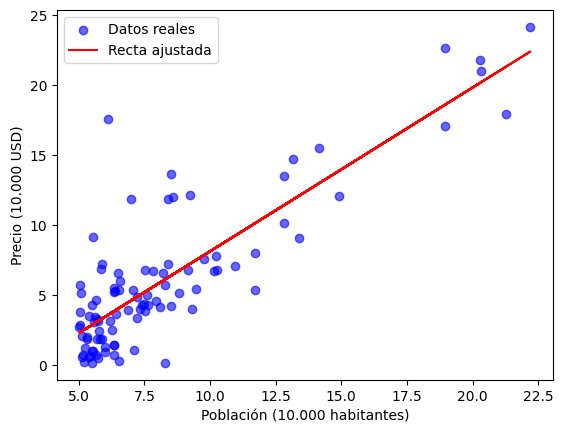

In [6]:
plt.scatter(X, y, color='blue', alpha=0.6, label='Datos reales')

y_predicha = modelo_lineal.predict(X)
plt.plot(X, y_predicha, color='red', label='Recta ajustada')

plt.xlabel('Población (10.000 habitantes)')
plt.ylabel('Precio (10.000 USD)')
plt.legend()
plt.show()

**Interpretación de la pendiente:** analizamos qué representa numéricamente el valor de la pendiente obtenida dentro del contexto real del problema (poblaciones y precios).

La pendiente obtenida en nuestro modelo es $w_1 = 1.1698$.

- **Interpretación del signo:** El signo positivo indica que existe una relación lineal directa (positiva) entre la población de la ciudad y el precio de las viviendas, a medida que aumente la población, el precio de las viviendas también aumenta.
- **Interpretación de la magnitud:** teniendo en cuanta que la variable de entrada (x) está en unidades de 10.000 habitantes (1x = 10.000 habitantes) y la variable objetivo (y) en unidades de 10.000 dólares (1y = 10.000 dólares), por cada unidad que x aumente, y va a aumentar una magnitud de 1.1698 unidades, por lo que el precio de la vivienda aumenta en promedio 11.698 dólares por cada 10.000 habitantes (calculado como $1.1698 \times 10.000$).

### **Actividad 2:**

In [7]:
data2 = pd.read_csv('data/data_2.csv')

X = data2[['X']].values
y = data2['y'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
modelo_lineal2 = LinearRegression()
modelo_lineal2.fit(X_train, y_train)

LinearRegression()

In [9]:
y_train_pred = modelo_lineal2.predict(X_train)
y_test_pred = modelo_lineal2.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)
r2_train= r2_score(y_train, y_train_pred)

mse_test= mean_squared_error(y_test, y_test_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)
r2_test= r2_score(y_test, y_test_pred)

print(f"Train --> MSE: {mse_train:.4f} | RMSE: {rmse_train:.4f} | R2: {r2_train:.4f}")
print(f"Test --> MSE: {mse_test:.4f} | RMSE: {rmse_test:.4f} | R2: {r2_test:.4f}")

Train --> MSE: 4.3114 | RMSE: 2.0764 | R2: 0.9154
Test --> MSE: 4.3080 | RMSE: 2.0756 | R2: 0.9151


**Comparacion**

Los errores en el entrenamiento y prueba son prácticamente iguales (MSE ≈ 4.31 y R² ≈ 0.915 en ambos conjuntos). Esto demuestra que el modelo generaliza correctamente. No tenemos indicios de overfitting, ya que un modelo sobreajustado mostraría un error mucho menor en train que en test. Tampoco hay señales de underfitting, un R² de 0.915 indica que el modelo captura la mayoría de variciones en los datos.

### **Actividad 3:**

En esta actividad vamos a explorar la regresión polinomial, que nos permite ajustar curvas más flexibles agregando potencias de nuestra variable de entrada (ej. $x^2, x^3$), dado que se sabe que no siempre una recta es la mejor forma de representar datos. Probaremos polinomios de grados 1, 3, 7 y 13 sobre el archivo data_3.csv para comparar visualmente cómo la curva cambia y se vuelve cada vez más compleja a medida que el grado aumenta.

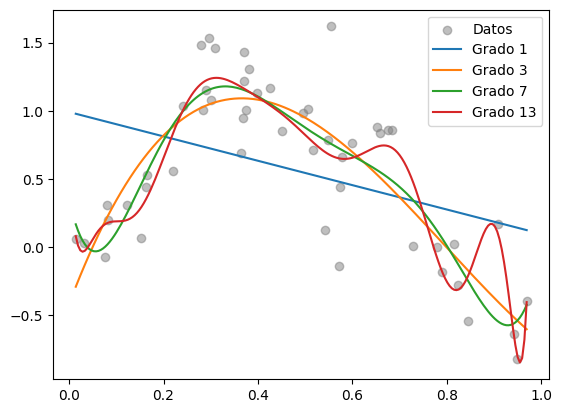

In [10]:
data3 = pd.read_csv('data/data_3.csv')
X3 = data3.iloc[:, 0].values.reshape(-1, 1)
y3 = data3.iloc[:, 1].values

X3_plot = np.linspace(X3.min(), X3.max(), 200).reshape(-1, 1)
plt.scatter(X3, y3, color='gray', alpha=0.5, label='Datos')

grados = [1, 3, 7, 13]
for d in grados:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(X3, y3)
    y_plot_pred = pipe.predict(X3_plot)
    plt.plot(X3_plot, y_plot_pred, label=f'Grado {d}')

plt.legend()

#### **Cómo cambia la forma de la función al aumentar el grado:**
A medida que aumentamos el grado del polinomio el modelo gana flexibilidad para curvarse y adaptarse a los puntos de entrenamiento:

* **Grado 1 (curva azul):** Es una línea recta demasiado rígida que no logra capturar la verdadera estructura curva de los datos. Esto es un claro ejemplo de subajuste (underfitting).

* **Grados 3 y 7 (curvas naranja y verde):** Logran capturar muy bien la tendencia principal de los puntos, subiendo y bajando sin hacer movimientos bruscos.

* **Grado 13 (Rojo):** la curva empieza a hacer oscilaciones muy marcadas para intentar acercarse lo más posible a cada punto individual. Está empezando a memorizar las variaciones aleatorias (ruido) en lugar de la tendencia real. Esto es un sobreajuste (overfitting).

No es posible decidir con certeza cuál generaliza mejor basándose únicamente en este gráfico visual sobre los datos de entrenamiento. Se requiere un conjunto de validación independiente para medir el error real.

Aunque visualmente podemos sospechar que los grados 3 o 7 son los más razonables y que el grado 13 está sobreajustando, este gráfico solo nos muestra los datos de entrenamiento. Para saber realmente cuál modelo generaliza mejor (cuál hace mejores predicciones frente a datos que nunca vio), es indispensable calcular el error (MSE) utilizando un conjunto de datos independiente (un conjunto de validación o prueba). El error de entrenamiento por sí solo siempre será menor cuanto mayor sea el grado, engañándonos sobre su verdadera capacidad predictiva.

### **Actividad 4:**

Si aumentamos mucho el grado del polinomio el modelo se puede volver tan complejo que memoriza el ruido de los datos (sobreajuste), fracasando con datos nuevos. En esta sección vamos a analizar el compromiso entre sesgo y varianza. Usando los datos de data_7.mat, ajustaremos modelos de varios grados distintos y compararemos su error, en el conjunto de entrenamiento y en un conjunto de validación, para identificar gráficamente en qué punto el modelo subajusta, sobreajusta, o hay equilibrio.

#### **Calculo de los valores (MSE y $R^2$):**

In [11]:
# Carga de los datos usando scipy (es un archivo .mat de MATLAB)
mat = scipy.io.loadmat('data/data_7.mat')
X7, y7 = mat['X'], mat['y'].ravel()           # Entrenamiento
X7val, y7val = mat['Xval'], mat['yval'].ravel() # Validación

grados = [1, 3, 5, 7, 9, 11, 13, 15]
mse_train, mse_val = [], []
r2_train, r2_val = [], []

# Se ajustan modelos y calculamos las métricas para cada grado
for d in grados:
    # Pipeline: crea el polinomio (poly), escala los datos (scaler) y ajusta la regresión (lr)
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(X7, y7)
    
    # Predicciones para ambos conjuntos
    y7_pred = pipe.predict(X7)
    y7val_pred = pipe.predict(X7val)
    
    # MSE
    mse_train.append(mean_squared_error(y7, y7_pred))
    mse_val.append(mean_squared_error(y7val, y7val_pred))
    
    # Guardamos el R^2
    r2_train.append(r2_score(y7, y7_pred))
    r2_val.append(r2_score(y7val, y7val_pred))

#### **Valores calculados en la parte anterior:**

In [12]:
grados = [1, 3, 5, 7, 9, 11, 13, 15]
resultados_tabla = []

for d in grados:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(X7, y7)
    
    y7_pred = pipe.predict(X7)
    y7val_pred = pipe.predict(X7val)
    
    # Guardamos los resultados de esta vuelta (iteración) en un diccionario
    resultados_tabla.append({
        'Grado': d,
        'MSE Entrenamiento': mean_squared_error(y7, y7_pred),
        'R2 Entrenamiento': r2_score(y7, y7_pred),
        'MSE Validación': mean_squared_error(y7val, y7val_pred),
        'R2 Validación': r2_score(y7val, y7val_pred)
    })
df_resultados = pd.DataFrame(resultados_tabla)
df_resultados.set_index('Grado', inplace=True)
df_resultados = df_resultados.round(4)
display(df_resultados)

,MSE Entrenamiento,R2 Entrenamiento,MSE Validación,R2 Validación
Grado,,,,
1,62.0071,0.6553,25.8297,0.3446
3,14.2834,0.9206,9.1812,0.7670
5,13.6581,0.9241,6.3040,0.8400
7,4.7258,0.9737,71.6069,-0.8169
9,2.1349,0.9881,29.0968,0.2617
11,1.7527,0.9903,23.0155,0.4160
13,1.6515,0.9908,167.2563,-3.2439
15,1.5737,0.9913,256.3906,-5.5055


#### **Graficación de los valores de MSE:**

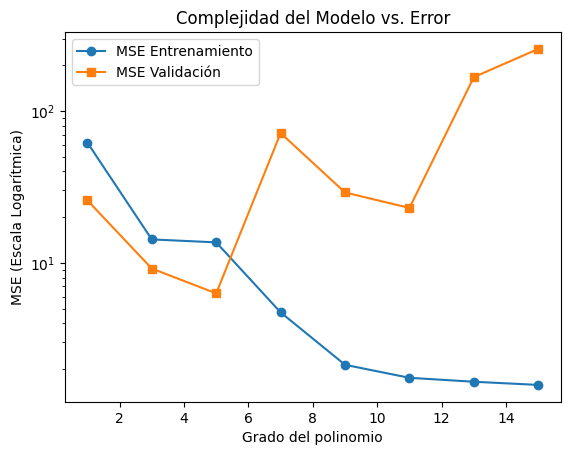

In [13]:
# Graficamos MSE de entrenamiento y validación en función del grado
plt.plot(grados, mse_train, marker='o', label='MSE Entrenamiento')
plt.plot(grados, mse_val, marker='s', label='MSE Validación')

# Se usa una escala logarítmica porque el error de validación toma valores muy altos
plt.yscale('log') 
plt.xlabel('Grado del polinomio')
plt.ylabel('MSE (Escala Logarítmica)')
plt.title('Complejidad del Modelo vs. Error')
plt.legend()
plt.show()

#### **Subajuste (underfitting), buen compromiso y sobreajuste (overfitting):**

A partir del gráfico y la tabla, podemos distinguir claramente las diferentes etapas de la complejidad del modelo:  

* **Underfitting:** El polinomio de grado 1 es un modelo demasiado simple y rígido, lo que resulta en un MSE muy alto (62.00) y un $R^2$ pobre (0.65) durante el entrenamiento, fallando también en la validación.  
* **Buen compromiso:** Se observa en los grados 3 y 5. Ambos reducen significativamente el error, pero el grado 5 logra el equilibrio perfecto, alcanzando el MSE de validación más bajo de toda la tabla (6.30) y el mejor $R^2$ predictivo (0.84).
* **Overfitting:** A partir del grado 7. El MSE de entrenamiento continúa bajando (llegando a 1.57 en el grado 15), pero el MSE de validación aumenta drásticamente y los valores de $R^2$ se vuelven negativos. El modelo se adaptó demasiado al ruido de los datos de entrenamiento y perdió toda capacidad de generalizar.  

**¿Qué otros criterios podrían utilizarse para preferir un modelo sobre otro si presentan desempeños de validación muy similares?**

Si dos modelos tuvieran un MSE de validación casi idéntico, deberíamos elegir basándonos en:

* **Principio de Parsimonia (Navaja de Ockham):** Ante la igualdad, siempre se debe preferir el modelo más simple (oseá el de menor grado).
* **Costo computacional:** Un modelo más simple requiere menos recursos de memoria y tiempo para entrenar y ejecutar predicciones.
* **Estabilidad y facilidad de interpretación:** Un modelo complejo se vuelve impredecible, en los espacios sin datos, la curva hace picos y caídas sin sentido. También se sabe que al calcular potencias tan grandes (ej. $x^15$) la computadora empieza a tener errores matemáticos al procesar los números, y la fórmula resulta tan gigante que es imposible de entender para una persona.  

### **Actividad 5**

In [14]:
grados = [1, 3, 5, 7, 9, 11, 13, 15]

modelos = {
    "Sin regularizacion": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0, max_iter=10000),
    "Elastic Net": ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000),
}

resultados_reg = []
for d in grados:
    for nombre, modelo in modelos.items():
        pipe = Pipeline([
            ('poly', PolynomialFeatures(degree=d)),
            ('scaler', StandardScaler()),
            ('modelo', modelo)
        ])
        pipe.fit(X7, y7)
        mse_val = mean_squared_error(y7val, pipe.predict(X7val))
        resultados_reg.append({"Grado": d, "Modelo": nombre, "MSE Validacion": mse_val})

df_resultados_reg = pd.DataFrame(resultados_reg)
tabla_reg = df_resultados_reg.pivot(index="Grado", columns="Modelo", values="MSE Validacion")
print(tabla_reg.round(3))

Modelo  Elastic Net   Lasso   Ridge  Sin regularizacion
Grado                                                  
1             9.722  19.148  24.259              25.830
3             3.207   6.710   8.059               9.181
5             6.347   4.940   6.283               6.304
7             8.010   4.632   4.689              71.607
9             8.023   4.632   4.479              29.097
11            7.093   4.632   8.743              23.015
13            6.185   4.632  18.919             167.256
15            5.738   4.632  33.982             256.391


**Comparación**

La tabla muestra el MSE de validación para las cuatro variantes en cada grado. Se observa:
